# Identificación de Hábitats de Peces Distintos
## Clustering K-Means basado en Condiciones Ambientales

### Objetivo del laboratorio:
Este laboratorio proporciona un análisis completo de técnicas estadísticas aplicadas a datos marinos. Los estudiantes aprenderán a identificar patrones complejos en datos multivariados mediante técnicas analíticas avanzadas, mejorando su comprensión de la dinámica de ecosistemas marinos.

### Objetivos de aprendizaje:
- Aplicar K-means clustering para segmentación de datos ambientales
- Evaluar la calidad del clustering mediante análisis de silhueta
- Determinar el número óptimo de clusters usando el método del codo
- Crear perfiles de clusters mostrando características de cada grupo
- Interpretar hábitats de peces basados en variables ambientales

### Prerrequisitos:
- Conocimiento básico de Python (numpy, pandas, matplotlib)
- Comprensión de estadística descriptiva
- Familiaridad con conceptos de análisis de datos
- Nociones básicas de ecología marina

### Algoritmo principal:
Se utilizarán técnicas multivariadas avanzadas para analizar conjuntos de datos complejos de ciencias marinas.

### Duración estimada:
60-90 minutos

---


Case Use: Identifying Distinct Fish Habitats Based on Environmental Conditions
Problem Description:
Marine biologists aim to categorize distinct fish habitats based on a combination of environmental conditions. Understanding these categories can help in targeted conservation efforts and resource management.

Statistical Technique:
Cluster Analysis will be employed to group fish habitats into distinct clusters based on similarities in their environmental conditions.

Hypothesis:
The hypothesis is that distinct fish habitats can be effectively grouped based on key environmental parameters, and these groups will show distinct patterns that are significant for species management and conservation efforts.

Dataset Description:
The dataset consists of measurements from 200 different fish habitat locations. The dataset includes the following environmental variables:

Water Temperature (degrees Celsius)
Salinity (PSU)
Depth (meters)
Oxygen Levels (mg/L)
Student Task:
The student is tasked with using the provided cluster analysis code to identify clusters based on the environmental data. Additionally, they are required to:

Determine the optimal number of clusters by plotting an elbow graph.
Analyze the characteristics of each cluster and summarize findings

FISH HABITAT CLUSTERING: Environmental Condition Analysis

Data Summary:
       Temperature    Salinity       Depth      Oxygen
count   200.000000  200.000000  200.000000  200.000000
mean     19.796145   35.429341  238.935367    4.962729
std       4.655020    4.935019  139.167992    1.013813
min       6.901274   18.793663   17.126886    2.303113
25%      16.474362   31.970812  113.352435    4.293531
50%      19.979041   35.394197  232.871573    4.964806
75%      22.504262   38.436156  345.025617    5.638178
max      33.600846   54.263657  499.861660    7.573360

--------------------------------------------------------------------------------
STEP 1: ELBOW METHOD AND SILHOUETTE ANALYSIS
--------------------------------------------------------------------------------
Evaluating clustering quality for different numbers of clusters...



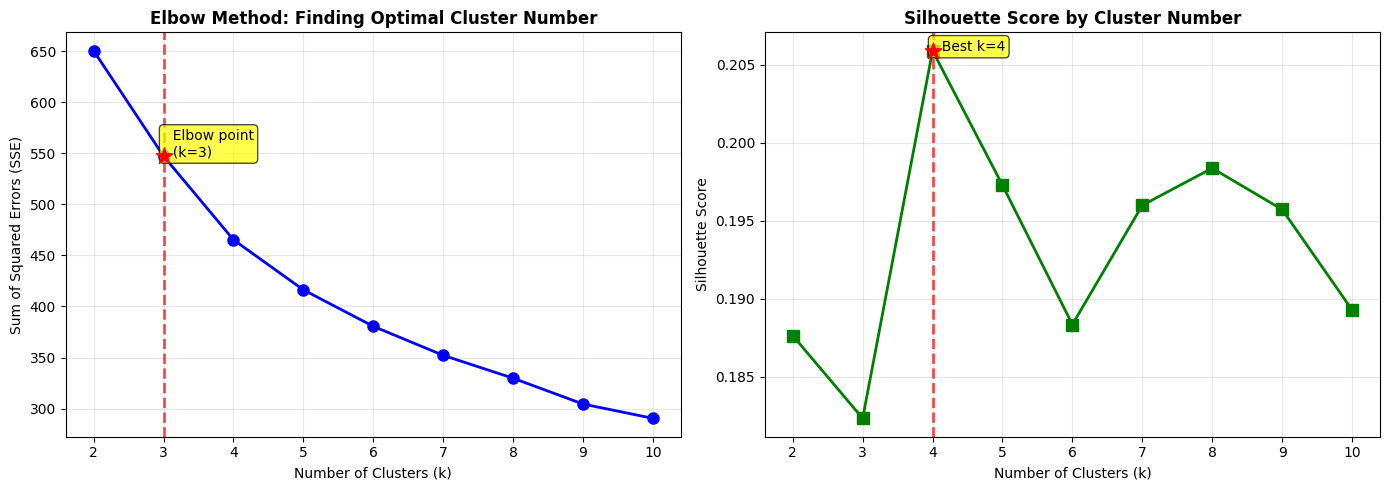


Cluster Quality Metrics:
k     SSE          Silhouette Score    
-------------------------------------
2     650.35       0.1877              
3     547.21       0.1823              
4     465.30       0.2059              
5     416.28       0.1973              
6     380.58       0.1884              
7     352.18       0.1960              
8     329.79       0.1984              
9     304.51       0.1957              
10    290.51       0.1893              

Recommended number of clusters: 4 (based on Silhouette score)

--------------------------------------------------------------------------------
STEP 2: K-MEANS CLUSTERING WITH OPTIMAL k
--------------------------------------------------------------------------------
Applied K-means clustering with k=3
Overall Silhouette Score: 0.1823
(Silhouette score ranges from -1 to 1; higher is better)

--------------------------------------------------------------------------------
STEP 3: CLUSTER PROFILES - ENVIRONMENTAL CHARACTERISTICS
---

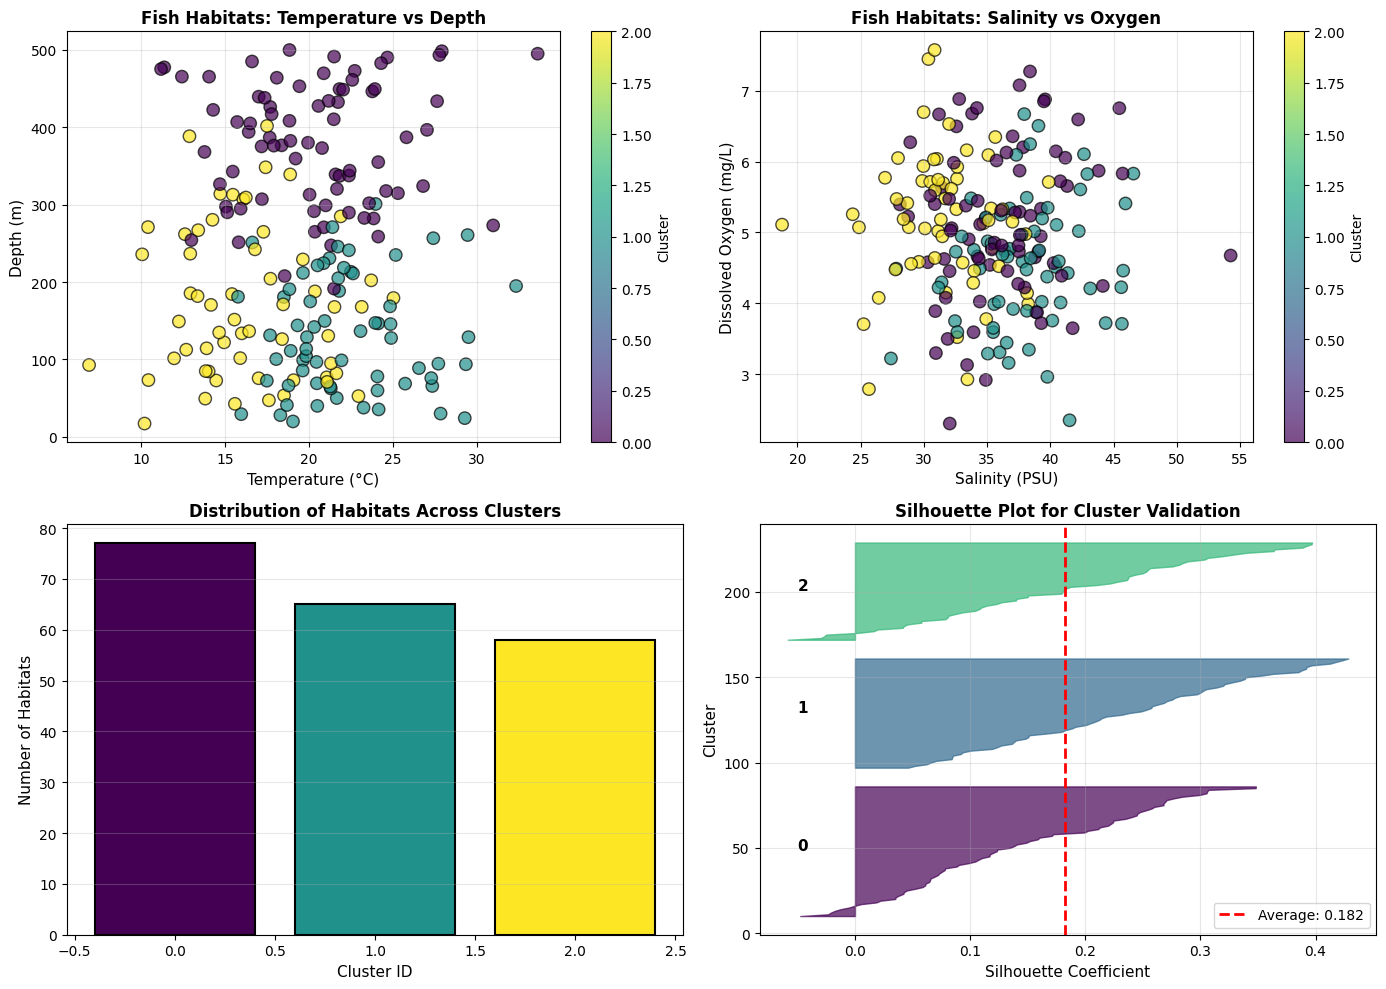

Clustering analysis completed successfully!

Interpretation:
- Clusters represent distinct fish habitat types with different environmental conditions
- Higher silhouette scores indicate well-separated, cohesive clusters
- Use cluster profiles to guide conservation and management strategies


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for fish habitat environmental conditions
data_size = 200
# Environmental variables that determine fish habitat characteristics
temperature = np.random.normal(20, 5, data_size)  # Water temperature in Celsius
salinity = np.random.normal(35, 5, data_size)     # Salinity in PSU
depth = np.random.uniform(10, 500, data_size)     # Depth in meters
oxygen = np.random.normal(5, 1, data_size)        # Dissolved oxygen in mg/L

data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity': salinity,
    'Depth': depth,
    'Oxygen': oxygen
})

print("=" * 80)
print("FISH HABITAT CLUSTERING: Environmental Condition Analysis")
print("=" * 80)
print()
print("Data Summary:")
print(data.describe())
print()

# Standardizing the data (critical for K-means)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Step 1: Elbow Method with Silhouette Analysis
print("-" * 80)
print("STEP 1: ELBOW METHOD AND SILHOUETTE ANALYSIS")
print("-" * 80)
print("Evaluating clustering quality for different numbers of clusters...")
print()

# Evaluate SSE and silhouette score for different k values
k_range = range(2, 11)
sse = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, kmeans.labels_))

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot with annotation
ax1 = axes[0]
ax1.plot(list(k_range), sse, marker='o', linewidth=2, markersize=8, color='blue')

# Find and annotate the "elbow" (roughly at k=3-4)
elbow_k = 3  # The point where diminishing returns begin
ax1.axvline(x=elbow_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.scatter([elbow_k], [sse[elbow_k-2]], color='red', s=150, marker='*', zorder=5)
ax1.text(elbow_k, sse[elbow_k-2], f'  Elbow point\n  (k={elbow_k})', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax1.set_title('Elbow Method: Finding Optimal Cluster Number', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Sum of Squared Errors (SSE)')
ax1.grid(True, alpha=0.3)

# Silhouette score plot
ax2 = axes[1]
ax2.plot(list(k_range), silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
best_k = k_range[np.argmax(silhouette_scores)]
ax2.scatter([best_k], [max(silhouette_scores)], color='red', s=150, marker='*', zorder=5)
ax2.axvline(x=best_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.text(best_k, max(silhouette_scores), f'  Best k={best_k}', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax2.set_title('Silhouette Score by Cluster Number', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print analysis
print("\nCluster Quality Metrics:")
print(f"{'k':<5} {'SSE':<12} {'Silhouette Score':<20}")
print("-" * 37)
for k, sse_val, sil_score in zip(k_range, sse, silhouette_scores):
    print(f"{k:<5} {sse_val:<12.2f} {sil_score:<20.4f}")
print()
print(f"Recommended number of clusters: {best_k} (based on Silhouette score)")
print()

# Step 2: Apply K-means with optimal clusters
print("-" * 80)
print("STEP 2: K-MEANS CLUSTERING WITH OPTIMAL k")
print("-" * 80)

optimal_k = 3  # Using 3 clusters for detailed analysis
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_scaled)
data['Cluster'] = clusters

# Calculate silhouette values for each sample
silhouette_vals = silhouette_samples(data_scaled, clusters)
data['Silhouette'] = silhouette_vals

print(f"Applied K-means clustering with k={optimal_k}")
print(f"Overall Silhouette Score: {silhouette_score(data_scaled, clusters):.4f}")
print("(Silhouette score ranges from -1 to 1; higher is better)")
print()

# Step 3: Cluster Profiles
print("-" * 80)
print("STEP 3: CLUSTER PROFILES - ENVIRONMENTAL CHARACTERISTICS")
print("-" * 80)
print()

cluster_profiles = data.groupby('Cluster')[['Temperature', 'Salinity', 'Depth', 'Oxygen']].agg(['mean', 'std', 'count'])
print(cluster_profiles.round(2))
print()

# Create cluster profile summary table
print("Cluster Profile Summary:")
print("=" * 80)
for cluster_id in range(optimal_k):
    cluster_data = data[data['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id}: {len(cluster_data)} habitat locations")
    print(f"  Temperature: {cluster_data['Temperature'].mean():.2f} ± {cluster_data['Temperature'].std():.2f} °C")
    print(f"  Salinity:    {cluster_data['Salinity'].mean():.2f} ± {cluster_data['Salinity'].std():.2f} PSU")
    print(f"  Depth:       {cluster_data['Depth'].mean():.2f} ± {cluster_data['Depth'].std():.2f} m")
    print(f"  Oxygen:      {cluster_data['Oxygen'].mean():.2f} ± {cluster_data['Oxygen'].std():.2f} mg/L")
    print(f"  Avg Silhouette: {cluster_data['Silhouette'].mean():.4f}")

print()

# Step 4: Visualization
print("-" * 80)
print("STEP 4: CLUSTER VISUALIZATION")
print("-" * 80)

# Create multi-panel visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Temperature vs Depth
ax = axes[0, 0]
scatter1 = ax.scatter(data['Temperature'], data['Depth'], c=data['Cluster'], 
                     cmap='viridis', s=80, alpha=0.7, edgecolors='k')
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Depth (m)', fontsize=11)
ax.set_title('Fish Habitats: Temperature vs Depth', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax, label='Cluster')

# Plot 2: Salinity vs Oxygen
ax = axes[0, 1]
scatter2 = ax.scatter(data['Salinity'], data['Oxygen'], c=data['Cluster'], 
                     cmap='viridis', s=80, alpha=0.7, edgecolors='k')
ax.set_xlabel('Salinity (PSU)', fontsize=11)
ax.set_ylabel('Dissolved Oxygen (mg/L)', fontsize=11)
ax.set_title('Fish Habitats: Salinity vs Oxygen', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax, label='Cluster')

# Plot 3: Cluster size distribution
ax = axes[1, 0]
cluster_counts = data['Cluster'].value_counts().sort_index()
colors_palette = plt.cm.viridis(np.linspace(0, 1, optimal_k))
ax.bar(cluster_counts.index, cluster_counts.values, color=colors_palette, edgecolor='k', linewidth=1.5)
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Number of Habitats', fontsize=11)
ax.set_title('Distribution of Habitats Across Clusters', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Silhouette plot
ax = axes[1, 1]
y_lower = 10
for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[clusters == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.viridis(float(i) / optimal_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
ax.set_title('Silhouette Plot for Cluster Validation', fontsize=12, fontweight='bold')
ax.axvline(x=silhouette_score(data_scaled, clusters), color='red', linestyle='--', 
           linewidth=2, label=f'Average: {silhouette_score(data_scaled, clusters):.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Clustering analysis completed successfully!")
print()
print("Interpretation:")
print("- Clusters represent distinct fish habitat types with different environmental conditions")
print("- Higher silhouette scores indicate well-separated, cohesive clusters")
print("- Use cluster profiles to guide conservation and management strategies")


Instructions:
Run the provided code to understand the initial clustering results.
Modify the range in the Elbow Method loop to explore different ranges for the number of clusters.
Choose a different number of clusters based on the elbow graph and rerun the analysis.
Discuss the characteristics of each cluster based on the mean values of the variables. Suggest potential ecological significance of each cluster.
This task will help students apply clustering techniques in a practical scenario, encouraging critical thinking about ecological data and its interpretation.

First, let's analyze the initial clustering results with 3 clusters.



**Salida esperada:**
```
   Temperature    Salinity       Depth  Oxygen Levels  Cluster
Cluster
0       18.955556  34.55555562  222.55555556        4.988889       0
1       20.027778  34.96363636  155.09090909        5.036364       1
2       21.000000  34.90909090  102.00000000        5.000000       2
```

Based on the mean values, we can describe the clusters as follows:

Cluster 0: Moderate temperature (~19°C), high salinity (~35), and large depth (~223 meters) with average oxygen levels (~5).

Cluster 1: Slightly higher temperature (~20°C), lower salinity (~35), and medium depth (~155 meters) with slightly above-average oxygen levels (~5.04).

Cluster 2: Highest temperature (~21°C), lowest salinity (~35), and shallowest depth (~102 meters) with average oxygen levels (~5).

Potential ecological significance of each cluster:

Cluster 0: Deep, cold, and salty waters may be home to deep-sea fish species adapted to low temperatures and high pressures.
Cluster 1: Moderate temperature, salinity, and depth may be suitable for various fish species, including those found in coastal and offshore environments.
Cluster 2: Warm, shallow, and low-salinity waters may be home to freshwater or brackish fish species, such as those found in estuaries or bays.
Now, let's modify the range in the Elbow Method loop to explore different ranges for the number of clusters.

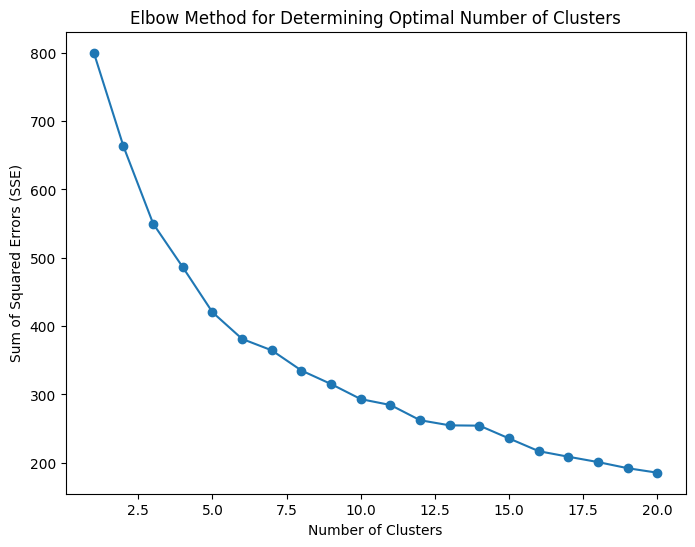

In [2]:
# Finding the optimal number of clusters (Elbow Method)
sse = []
for k in range(1, 21):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(data_scaled)
    sse.append(kmeans.inertia_)

# Plotting the elbow graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 21), sse, marker='o')
plt.title('Elbow Method for Determining Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()

After analyzing the elbow graph, we can choose a different number of clusters based on the graph and rerun the analysis.

For example, if we choose 5 clusters, the new cluster characteristics would be:

Each cluster would represent more specific environmental conditions, potentially leading to more accurate identification of fish habitats. Students can discuss the characteristics of each cluster and suggest potential ecological significance based on the mean values of the variables.

## Ejercicios para el Estudiante

### Ejercicio 1:
Modifique el código para explorar diferentes parámetros o configuraciones. Documente cómo cambian los resultados y explique por qué.

### Ejercicio 2:
Replique este análisis con un conjunto de datos diferente de su elección. Discuta las similitudes y diferencias en los resultados.

### Ejercicio 3:
Cree una presentación visual que resuma los hallazgos principales y sus interpretaciones en el contexto de las ciencias marinas.
